# Structural Interaction Analysis for Acarbose Alternatives

**Project:** Acarbose Alternative Drug Discovery  
**Notebook Purpose:** Analyze structural fingerprints of docked lead poses and compare them to experimental acarbose.   

**Key Questions**
- Are the lead ligands following a similar binding chemistry as acarbose? 
- If not, how do they differ?

**High-Level Takeaways**
- (fill this in last)

## 1. Setup & Imports

In [51]:
import oddt
import oddt.fingerprints as fp
import pandas as pd
import numpy as np
import glob

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from Bio.PDB import PDBParser, NeighborSearch
from rdkit import Chem
import umap

/Users/murto/anaconda3/envs/oddt_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading

In [2]:
proteins = ['2qmj', '3baj', '5nn8']

for protein in proteins:
    
    # load in protein
    protein_pdbqt = next(oddt.toolkit.readfile('pdbqt', f'../proteins/{protein}_cleaned.pdbqt'))
    protein_pdbqt.protein = True
    print(f"Loaded in protein: {protein}.")
    
    # instantiate empty df
    ifps_df = pd.DataFrame({
        'identifier': [],
        'IFP': [],
        'SIFP': [],
        'SPLIF': [],
        'PLEC': []
    })
    
    # grab candidates from corresponding leads dir
    candidates = sorted(glob.glob(f'../{protein}_actives_docked/*.sdf'))
    for candidate in candidates:
        
        # instantiate dict/row per lead
        interaction_data = {}
        lead = next(oddt.toolkit.readfile('sdf', candidate))
        
        # get fingerprints
        interaction_data['identifier'] = Path(candidate).stem
        interaction_data['IFP'] = fp.InteractionFingerprint(lead, protein_pdbqt)
        interaction_data['SIFP'] = fp.SimpleInteractionFingerprint(lead, protein_pdbqt, strict=False)
        interaction_data['SPLIF'] = fp.SPLIF(lead, protein_pdbqt)
        interaction_data['PLEC'] = fp.PLEC(lead, protein_pdbqt, size=16384, sparse=False)

        # create + concatenate df
        candidate_df = pd.DataFrame([interaction_data])
        ifps_df = pd.concat([ifps_df, candidate_df], ignore_index=True)
        print(f"Added data for {interaction_data['identifier']}.")
    
    
    print(f"Completed all docked ligands for {protein}. Saving to pickle...")
    ifps_df.to_pickle(f'{protein}_interaction_fps.pickle')

print('All proteins completed.')

Loaded in protein: 2qmj.
Added data for CNP0111740.3_out.
Added data for CNP0194690.2_out.
Added data for CNP0197699.2_out.
Added data for CNP0220759.1_out.
Added data for CNP0222412.1_out.
Added data for CNP0233949.3_out.
Added data for CNP0242257.2_out.
Added data for CNP0285045.1_out.
Added data for CNP0475805.2_out.
Completed all docked ligands for 2qmj. Saving to pickle...
Loaded in protein: 3baj.
Added data for CNP0032127.0_out.
Added data for CNP0064234.1_out.
Added data for CNP0064234.2_out.
Added data for CNP0073554.1_out.
Added data for CNP0086794.3_out.
Added data for CNP0101894.1_out.
Added data for CNP0103968.1_out.
Added data for CNP0124182.3_out.
Added data for CNP0146019.1_out.
Added data for CNP0146238.1_out.
Added data for CNP0146238.29_out.
Added data for CNP0147197.2_out.
Added data for CNP0148265.4_out.
Added data for CNP0151519.1_out.
Added data for CNP0154920.1_out.
Added data for CNP0156494.1_out.
Added data for CNP0156494.2_out.
Added data for CNP0160390.3_out.

In [3]:
ifps_2qmj = pd.read_pickle('2qmj_interaction_fps.pickle')
ifps_3baj = pd.read_pickle('3baj_interaction_fps.pickle')
ifps_5nn8 = pd.read_pickle('5nn8_interaction_fps.pickle')

## 3. Analysis & Visualization

### 3.1. Comparing PLECFP to experimental reference

In [5]:
def compute_interaction_fps(
    prot_path: str,
    lig_path: str,
    prot_fmt: str = "pdb",
    lig_fmt: str = "pdb",
    plec_size: int = 16384,
    plec_sparse: bool = False,
    sifp_strict: bool = False,
):
    """
    Compute interaction fingerprints between a protein and ligand.

    Returns a dict with keys: IFP, SIFP, SPLIF, PLEC
    """

    prot = next(oddt.toolkit.readfile(prot_fmt, prot_path))
    lig = next(oddt.toolkit.readfile(lig_fmt, lig_path))

    fps = {
        "IFP": fp.InteractionFingerprint(lig, prot),
        "SIFP": fp.SimpleInteractionFingerprint(lig, prot, strict=sifp_strict),
        "SPLIF": fp.SPLIF(lig, prot),
        "PLEC": fp.PLEC(lig, prot, size=plec_size, sparse=plec_sparse),
    }

    return fps

Calculating the experimental interaction fingerprint as a reference point.

In [12]:
experimental_2qmj = compute_interaction_fps(prot_path='../2QMJ/2QMJ_NOAC1.pdb', lig_path='../2QMJ/2QMJ_AC1.pdb')
experimental_3baj = compute_interaction_fps(prot_path='../3BAJ/3BAJ_NOARE.pdb', lig_path='../3BAJ/3BAJ_ARE.pdb')
experimental_5nn8 = compute_interaction_fps(prot_path='../5NN8/5NN8.pdb', lig_path='../5NN8/5NN8_AC1.pdb')

/Users/murto/anaconda3/envs/oddt_env/lib/python3.12/site-packages/oddt/toolkits/ob.py:475: UserWarning: Error while parsing molecule "../3BAJ/3BAJ_NOARE.pdb" for `atom_dict`. Atom #3946 (Ca) has 7 neighbors (max_neighbors=6). Additional neighbors are ignored.
  warnings.warn('Error while parsing molecule "%s" '


In [31]:
def add_similarity_scores(
    ifps_df,
    ref_ifp,
    source_col: str = "PLEC",
    dice_col: str = "PLEC_Dice",
    tanimoto_col: str = "PLEC_Tanimoto",
):
    """
    Add Dice and Tanimoto similarity scores vs a reference PLEC fingerprint.

    Parameters
    ----------
    ifps_df : pd.DataFrame
        DataFrame containing a column of PLEC fingerprints
    ref_ifp :
        Reference PLEC fingerprint
    plec_col : str
        Column name containing PLEC fingerprints
    dice_col : str
        Output column name for Dice similarity
    tanimoto_col : str
        Output column name for Tanimoto similarity
    """

    df = ifps_df.copy()

    df[dice_col] = df[source_col].apply(
        lambda x: fp.dice(ref_ifp, x)
    )

    df[tanimoto_col] = df[source_col].apply(
        lambda x: fp.tanimoto(ref_ifp, x)
    )

    return df


In [43]:
ref_ifp = experimental_5nn8["PLEC"]
ifps_5nn8 = add_similarity_scores(
    ifps_df=ifps_5nn8,
    ref_ifp=ref_ifp
)

ref_ifp = experimental_2qmj["PLEC"]
ifps_2qmj = add_similarity_scores(
    ifps_df=ifps_2qmj,
    ref_ifp=ref_ifp
)
ref_ifp = experimental_3baj["PLEC"]
ifps_3baj = add_similarity_scores(
    ifps_df=ifps_3baj,
    ref_ifp=ref_ifp
)

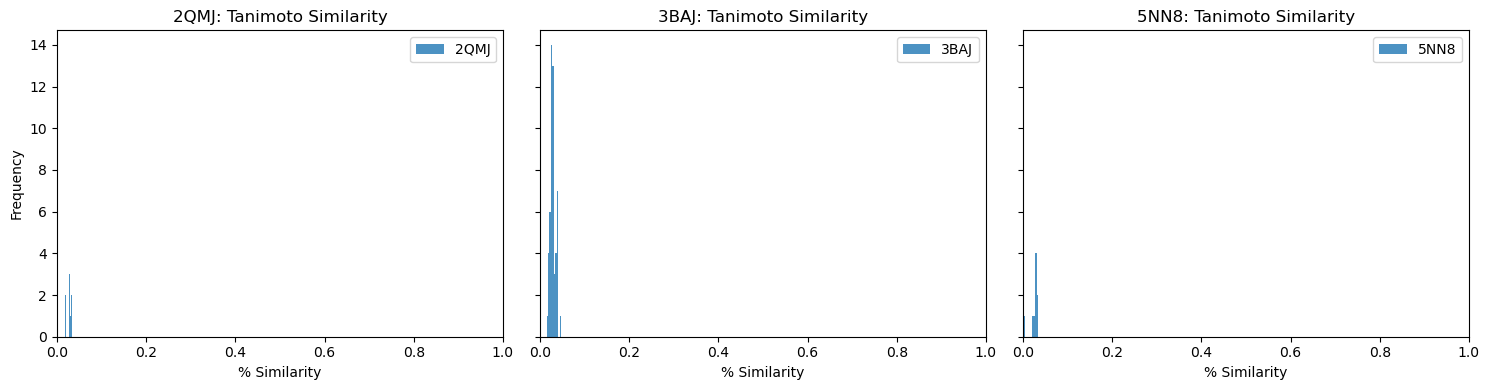

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

datasets = [
    (ifps_2qmj, "2QMJ"),
    (ifps_3baj, "3BAJ"),
    (ifps_5nn8, "5NN8"),
]

for ax, (df, name) in zip(axes, datasets):
    ax.hist(
        df["PLEC_Tanimoto"],
        bins=10,
        label=name,
        alpha=0.8
    )
    ax.set_xlim(0, 1)
    ax.set_title(f"{name}: Tanimoto Similarity")
    ax.set_xlabel("% Similarity")
    ax.legend()

axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 3.2. Residue contact matrices for each protein

In [28]:
def create_residue_contact_matrix(
    protein_pdb: str,
    ligand_dir: str,
    experimental_ligand_pdb: str | None = None,
    cutoff: float = 4.0,
    model_index: int = 0,
):
    """
    Create a residue × ligand contact matrix.
    A residue is True if any atom is within `cutoff` Å of any ligand atom.

    Protein: PDB
    Docked ligands: SDF (same frame)
    Experimental ligand: PDB (same frame)

    Returns
    -------
    contact_matrix : (n_ligands, n_residues) bool
    residue_labels : list[str]
    ligand_names   : list[str]
    """

    # ---- load protein ----
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure("protein", protein_pdb)
    model = list(struct.get_models())[model_index]

    residues = []
    residue_labels = []
    residue_to_index = {}

    for chain in model:
        for res in chain:
            if res.id[0] != " ":
                continue
            idx = len(residues)
            residues.append(res)
            residue_labels.append(f"{chain.id}:{res.get_resname()}{res.id[1]}")
            residue_to_index[(chain.id, res.id)] = idx

    if not residues:
        raise ValueError("No standard residues found in protein PDB.")

    # ---- neighbor search over protein atoms ----
    prot_atoms = [a for a in model.get_atoms() if a.get_parent().id[0] == " "]
    ns = NeighborSearch(prot_atoms)

    contact_rows = []
    ligand_names = []

    # ==========================================================
    # docked ligands (SDF)
    # ==========================================================
    ligand_dir = Path(ligand_dir)
    sdf_files = sorted(ligand_dir.glob("*.sdf"))

    if len(sdf_files) == 0:
        raise ValueError(f"No SDF ligands found in {ligand_dir}")

    for sdf_path in sdf_files:
        lig_name = sdf_path.stem.split("_")[0]
        ligand_names.append(lig_name)

        contacts = np.zeros(len(residues), dtype=bool)

        suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
        mol = next((m for m in suppl if m is not None), None)

        if mol is None or mol.GetNumConformers() == 0:
            contact_rows.append(contacts)
            continue

        conf = mol.GetConformer()
        lig_coords = np.array(
            [[conf.GetAtomPosition(i).x,
              conf.GetAtomPosition(i).y,
              conf.GetAtomPosition(i).z]
             for i in range(mol.GetNumAtoms())],
            dtype=float
        )

        for xyz in lig_coords:
            for atom in ns.search(xyz, cutoff, level="A"):
                res = atom.get_parent()
                chain = res.get_parent()
                idx = residue_to_index.get((chain.id, res.id))
                if idx is not None:
                    contacts[idx] = True

        contact_rows.append(contacts)

    # ==========================================================
    # experimental ligand (PDB)
    # ==========================================================
    if experimental_ligand_pdb is not None:
        lig_struct = parser.get_structure("exp_lig", experimental_ligand_pdb)
        lig_model = list(lig_struct.get_models())[model_index]

        contacts = np.zeros(len(residues), dtype=bool)

        lig_atoms = [
            a for a in lig_model.get_atoms()
            if a.get_parent().id[0] != " "  # hetero atoms
        ]

        for atom in lig_atoms:
            xyz = atom.coord
            for patom in ns.search(xyz, cutoff, level="A"):
                res = patom.get_parent()
                chain = res.get_parent()
                idx = residue_to_index.get((chain.id, res.id))
                if idx is not None:
                    contacts[idx] = True

        contact_rows.append(contacts)
        ligand_names.append("Experimental")

    contact_matrix = np.vstack(contact_rows)
    return contact_matrix, residue_labels, ligand_names

/var/folders/kw/ddpd6dfs6sl6s1nvpt91qqnr0000gn/T/ipykernel_78951/2620324170.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


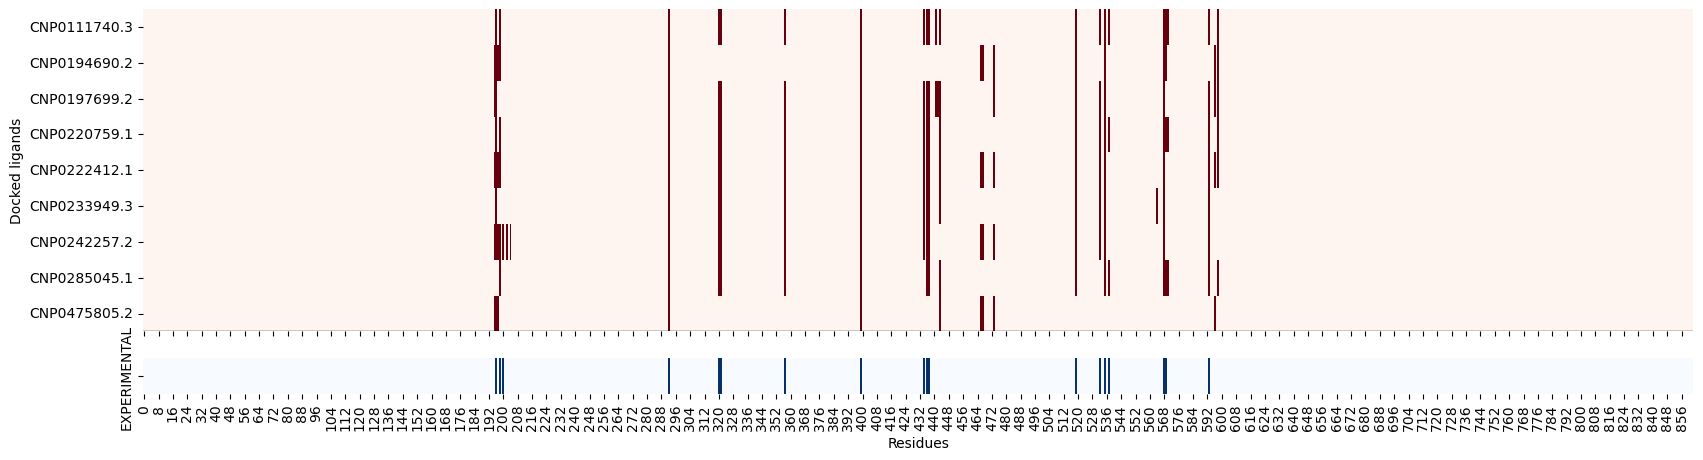

In [27]:
contacts, residues, ligands = create_residue_contact_matrix(
    protein_pdb="../2QMJ/2QMJ_NOAC1.pdb",
    ligand_dir="../2qmj_actives_docked/",
    experimental_ligand_pdb="../2QMJ/2QMJ_AC1.pdb",
    cutoff=4.0
)

contacts_docked = contacts[:-1]
contacts_exp = contacts[-1:]
ligands_docked = ligands[:-1]
ligand_exp = ligands[-1]

fig = plt.figure(figsize=(20, len(ligands_docked) / 3 + 2))

gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[len(ligands_docked), 1],
    hspace=0.15,
)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# ---------------------------
# docked ligands heatmap
# ---------------------------
sns.heatmap(
    contacts_docked.astype(int),
    ax=ax_top,
    yticklabels=ligands_docked,
    cmap="Reds",
    cbar=False
)

ax_top.set_ylabel("Docked ligands")
ax_top.tick_params(axis="x", labelbottom=False)

# ---------------------------
# experimental ligand heatmap
# ---------------------------
sns.heatmap(
    contacts_exp.astype(int),
    ax=ax_bot,
    yticklabels=[ligand_exp],
    cmap="Blues",      # <-- visually distinct
    cbar=False
)

#ax_bot.set_ylabel("Experimental")
ax_bot.set_xlabel("Residues")

# optional: draw separator line for extra clarity
ax_top.axhline(
    y=contacts_docked.shape[0],
    color="black",
    linewidth=1
)

plt.tight_layout()
plt.show()


/var/folders/kw/ddpd6dfs6sl6s1nvpt91qqnr0000gn/T/ipykernel_78951/3973980763.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


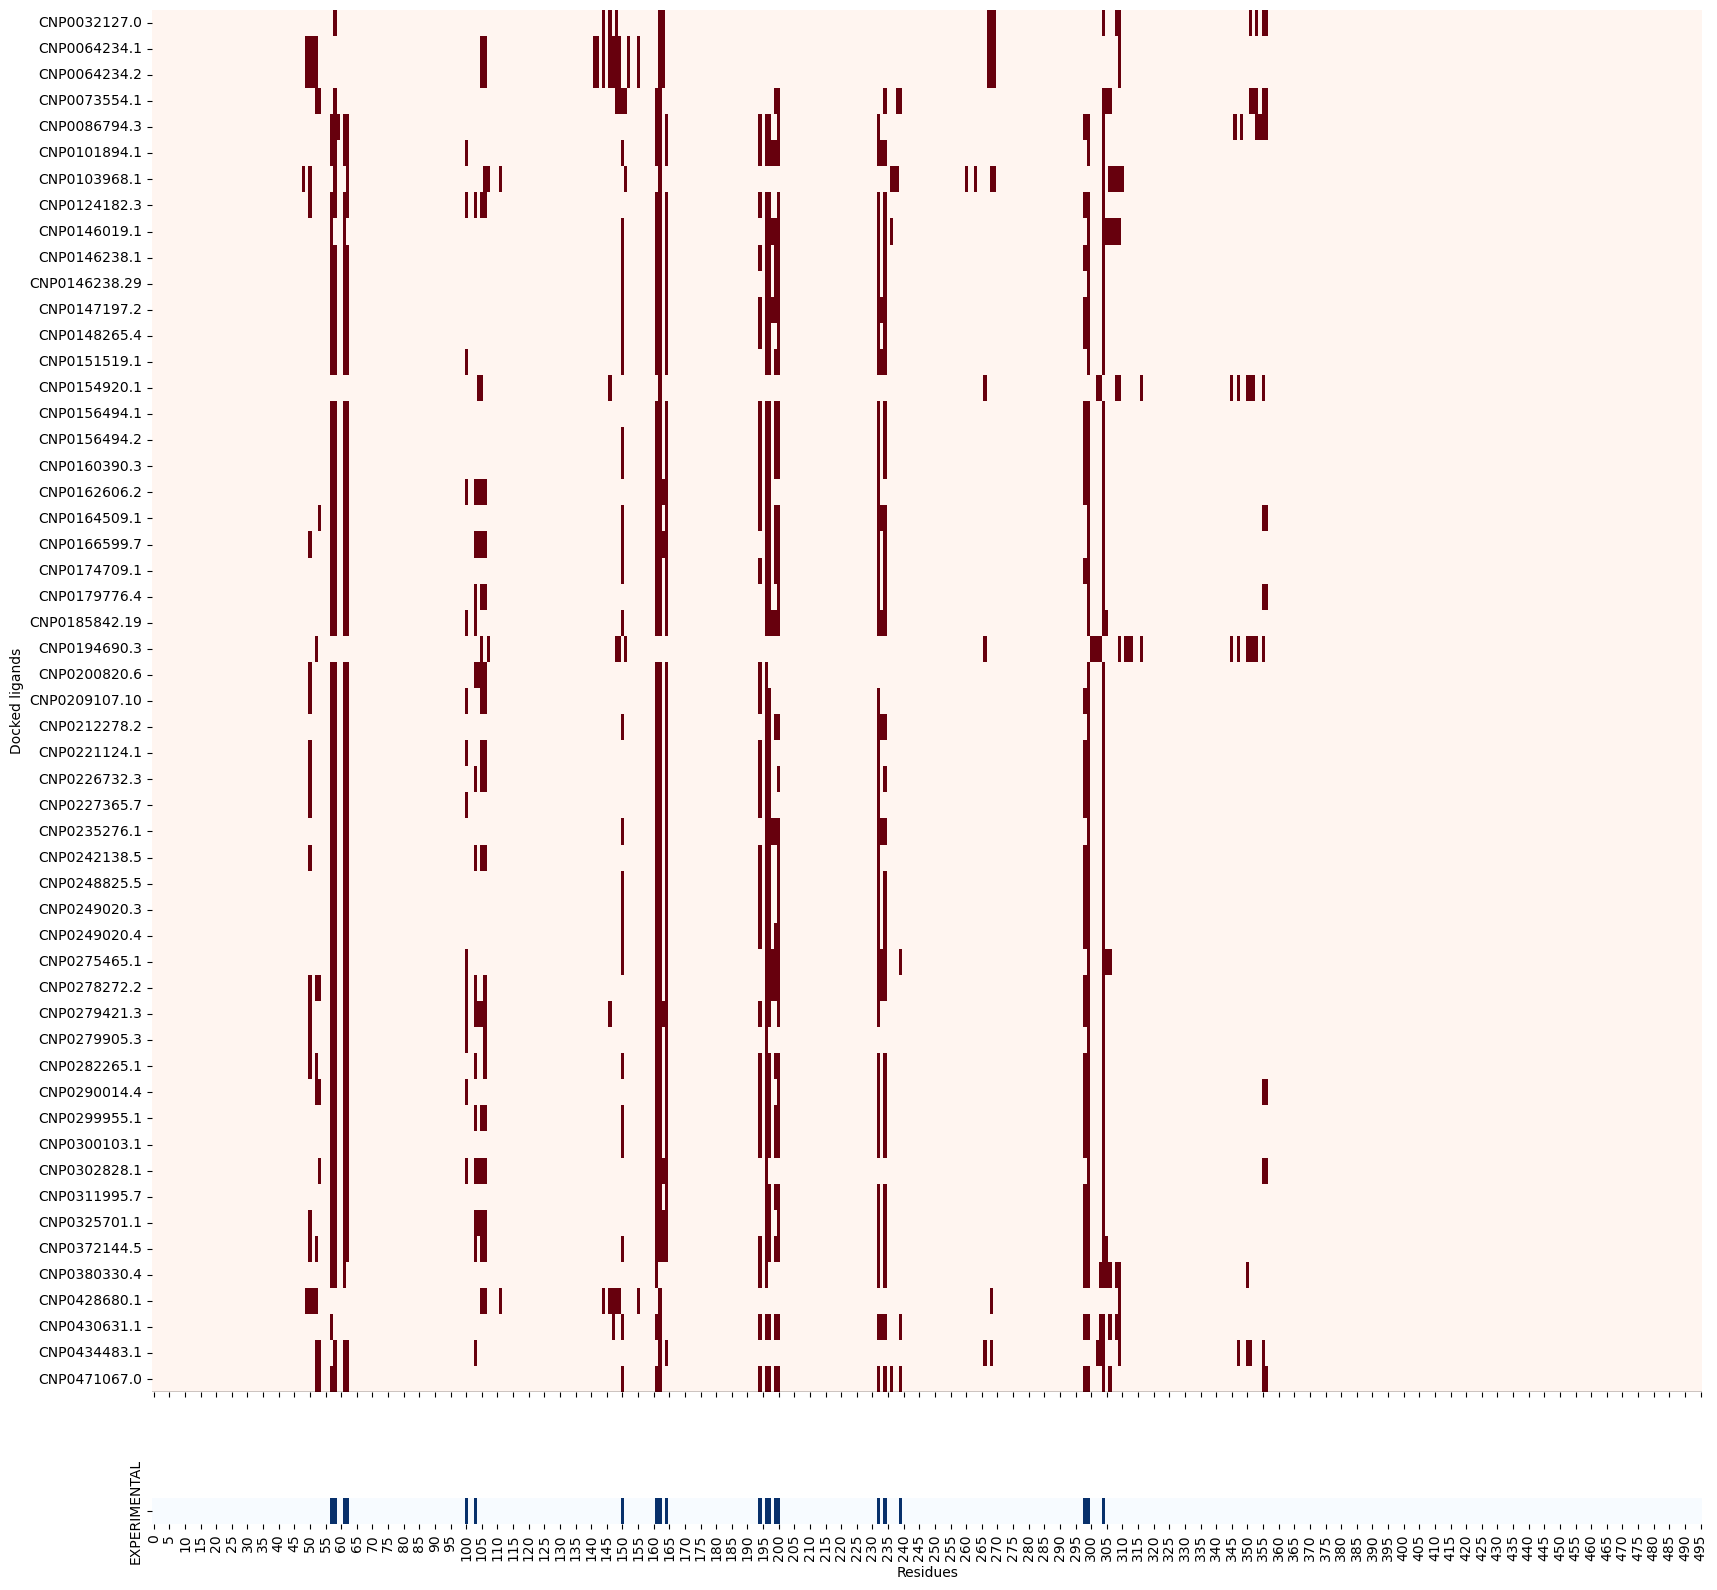

In [19]:
contacts, residues, ligands = create_residue_contact_matrix(
    protein_pdb="../3BAJ/3BAJ_NOARE.pdb",
    ligand_dir="../3baj_actives_docked/",
    experimental_ligand_pdb="../3BAJ/3BAJ_ARE.pdb",
    cutoff=4.0
)

contacts_docked = contacts[:-1]
contacts_exp = contacts[-1:]
ligands_docked = ligands[:-1]
ligand_exp = ligands[-1]

fig = plt.figure(figsize=(20, len(ligands_docked) / 3 + 2))

gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[len(ligands_docked), 1],
    hspace=0.15   # <-- spatial separation
)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# ---------------------------
# docked ligands heatmap
# ---------------------------
sns.heatmap(
    contacts_docked.astype(int),
    ax=ax_top,
    yticklabels=ligands_docked,
    cmap="Reds",
    cbar=False
)

ax_top.set_ylabel("Docked ligands")
ax_top.tick_params(axis="x", labelbottom=False)

# ---------------------------
# experimental ligand heatmap
# ---------------------------
sns.heatmap(
    contacts_exp.astype(int),
    ax=ax_bot,
    yticklabels=[ligand_exp],
    cmap="Blues",      # <-- visually distinct
    cbar=False
)

#ax_bot.set_ylabel("Experimental")
ax_bot.set_xlabel("Residues")

# optional: draw separator line for extra clarity
ax_top.axhline(
    y=contacts_docked.shape[0],
    color="black",
    linewidth=1
)

plt.tight_layout()
plt.show()


/var/folders/kw/ddpd6dfs6sl6s1nvpt91qqnr0000gn/T/ipykernel_78951/4280034677.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


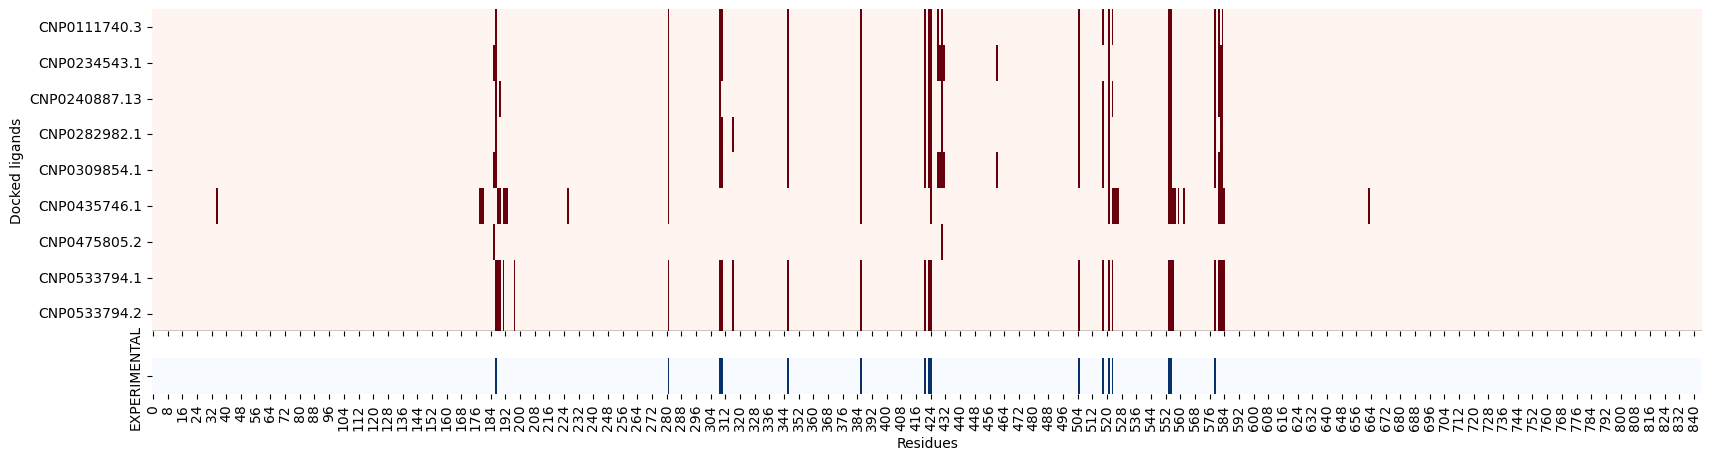

In [20]:
contacts, residues, ligands = create_residue_contact_matrix(
    protein_pdb="../5NN8/5NN8.pdb",
    ligand_dir="../5nn8_actives_docked/",
    experimental_ligand_pdb="../5NN8/5NN8_AC1.pdb",
    cutoff=4.0
)
contacts_docked = contacts[:-1]
contacts_exp = contacts[-1:]
ligands_docked = ligands[:-1]
ligand_exp = ligands[-1]

fig = plt.figure(figsize=(20, len(ligands_docked) / 3 + 2))

gs = gridspec.GridSpec(
    2, 1,
    height_ratios=[len(ligands_docked), 1],
    hspace=0.15   # <-- spatial separation
)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# ---------------------------
# docked ligands heatmap
# ---------------------------
sns.heatmap(
    contacts_docked.astype(int),
    ax=ax_top,
    yticklabels=ligands_docked,
    cmap="Reds",
    cbar=False
)

ax_top.set_ylabel("Docked ligands")
ax_top.tick_params(axis="x", labelbottom=False)

# ---------------------------
# experimental ligand heatmap
# ---------------------------
sns.heatmap(
    contacts_exp.astype(int),
    ax=ax_bot,
    yticklabels=[ligand_exp],
    cmap="Blues",     
    cbar=False
)

#ax_bot.set_ylabel("Experimental")
ax_bot.set_xlabel("Residues")
ax_top.axhline(
    y=contacts_docked.shape[0],
    color="black",
    linewidth=1
)

plt.tight_layout()
plt.show()

### 3.3. Pairwise PLECFP comparison & heatmap

In [58]:
def tanimoto_similarity_matrix(fps):
    """
    Compute NxN Tanimoto similarity matrix from ODDT fingerprints.

    Parameters
    ----------
    fps : list[np.ndarray]

    Returns
    -------
    S : np.ndarray, shape (N, N)
        Dice similarity matrix
    """
    n = len(fps)
    S = np.eye(n, dtype=float)

    for i in range(n):
        for j in range(i):
            s = fp.tanimoto(fps[i], fps[j])
            S[i, j] = s
            S[j, i] = s

    return S

def clustered_heatmap_from_tanimoto(
    S,
    labels=None,
    method="average",
    figsize=(8, 7)
):
    """
    Hierarchically clustered heatmap from Tanimoto similarity matrix.
    """
    # similarity -> distance
    D = 1.0 - S

    Z = linkage(squareform(D, checks=False), method=method)
    order = leaves_list(Z)

    S_ord = S[np.ix_(order, order)]

    plt.figure(figsize=figsize)
    plt.imshow(S_ord, aspect="auto")
    plt.colorbar(label="Tanimoto similarity")
    plt.title("Clustered PLECFP interaction similarity")

    if labels is not None:
        labels_ord = [labels[i] for i in order]
        plt.xticks(range(len(labels_ord)), labels_ord, rotation=90, fontsize=7)
        plt.yticks(range(len(labels_ord)), labels_ord, fontsize=7)
    else:
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

    return order, Z


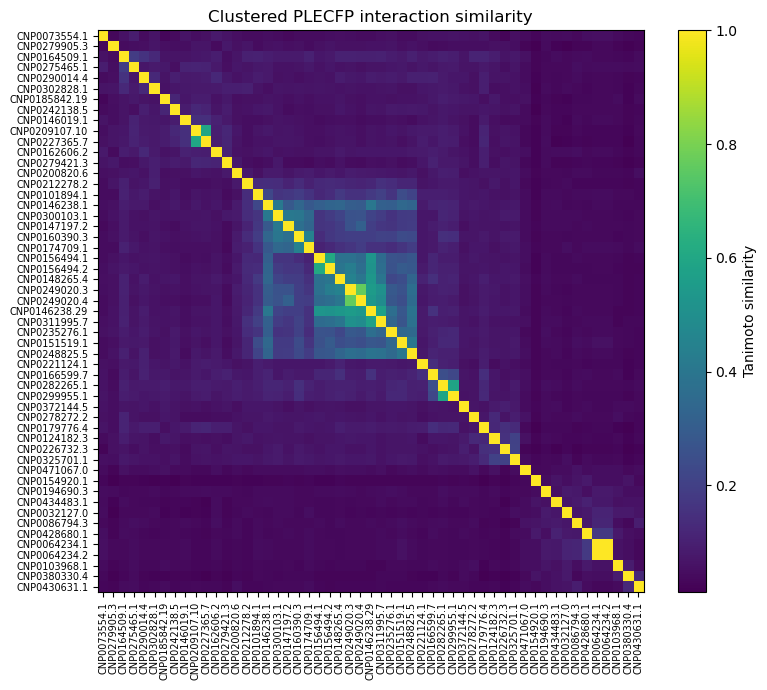

In [65]:
ligand_labels = [x.split('_')[0] for x in ifps_3baj.identifier.to_list()]
S = tanimoto_similarity_matrix(ifps_3baj.PLEC.to_list())
order, Z = clustered_heatmap_from_tanimoto(S, labels=ligand_labels)

## 4. Results & Interpretation

There appears to be little to no correlation between the experimental protein-ligand binding fingerprints and the computationally determined leads' fingerprints. However, all ligands appear to bind at similar residues of the binding pocket. This suggests lead candidates interact with largely the same residues, but via different interactions.

Some of the lead ligands for 3BAJ, such as CNP0146238.29, seem to share similarities with the binding behaviours of other leads, such as CNP0156494. 